# Music Mood Classifier — Part 2: Preprocessing & Feature Engineering

This notebook applies all data cleaning, outlier handling, feature engineering, and scaling steps. It then saves the fitted preprocessing pipeline, the label encoder, and the train/validation/test arrays as artifacts for use in Notebook 3 (model training).

**Run order:** This notebook must be run before Notebook 3.

**Notebooks in this series:**
1. Data Loading & Exploratory Data Analysis
2. Preprocessing & Feature Engineering *(this notebook)*
3. Model Selection, Tuning & Training
4. Model Evaluation


## 1. Setup


In [20]:
!pip install --upgrade lightgbm optuna mako alembic --quiet
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')


Libraries loaded.


## 2. Configuration

All settings are defined here as plain Python variables.


In [21]:
# ==== Configuration ====
DATA_PATH       = Path('dataset.csv')
ARTIFACTS_DIR   = Path('artifacts')
MODELS_DIR      = Path('models')

RANDOM_SEED     = 42
TARGET_COLUMN   = 'track_genre'
INDEX_COLUMN    = 'Unnamed: 0'
BOOL_COLUMN     = 'explicit'

DROP_COLUMNS = ['track_id', 'artists', 'album_name', 'track_name']

NUMERIC_FEATURES = [
    'popularity', 'duration_ms', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
]

# Outlier clipping: IQR-based Winsorisation with a conservative multiplier
IQR_MULTIPLIER = 3.0
CLIP_FEATURES = [
    'duration_ms', 'tempo', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
]

# Train / validation / test ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Ensure output directories exist
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration ready.')
print(f'  Data path      : {DATA_PATH}')
print(f'  Artifacts dir  : {ARTIFACTS_DIR}')
print(f'  Models dir     : {MODELS_DIR}')


Configuration ready.
  Data path      : dataset.csv
  Artifacts dir  : artifacts
  Models dir     : models


## 3. Genre Taxonomy Mapping

Define the 114-to-6 mapping inline so this notebook is self-contained.


In [22]:
GENRE_MAPPING = {
    # --- acoustic ---
    'acoustic': 'acoustic', 'folk': 'acoustic', 'singer-songwriter': 'acoustic',
    'songwriter': 'acoustic', 'country': 'acoustic', 'bluegrass': 'acoustic',
    'honky-tonk': 'acoustic', 'guitar': 'acoustic', 'blues': 'acoustic',
    'jazz': 'acoustic', 'groove': 'acoustic', 'ambient': 'acoustic',
    'new-age': 'acoustic', 'sleep': 'acoustic', 'study': 'acoustic',
    'chill': 'acoustic', 'piano': 'acoustic', 'classical': 'acoustic',
    'opera': 'acoustic', 'romance': 'acoustic', 'sad': 'acoustic',
    # --- alternative ---
    'alternative': 'alternative', 'alt-rock': 'alternative', 'indie': 'alternative',
    'indie-pop': 'alternative', 'grunge': 'alternative', 'british': 'alternative',
    'psych-rock': 'alternative', 'garage': 'alternative', 'rock': 'alternative',
    'hard-rock': 'alternative', 'rock-n-roll': 'alternative', 'rockabilly': 'alternative',
    # --- dance ---
    'pop': 'dance', 'dance': 'dance', 'disco': 'dance', 'party': 'dance',
    'power-pop': 'dance', 'pop-film': 'dance', 'happy': 'dance',
    'synth-pop': 'dance', 'gospel': 'dance', 'soul': 'dance', 'r-n-b': 'dance',
    'funk': 'dance', 'latin': 'dance', 'latino': 'dance', 'reggaeton': 'dance',
    'dancehall': 'dance', 'salsa': 'dance', 'samba': 'dance', 'sertanejo': 'dance',
    'forro': 'dance', 'pagode': 'dance', 'mpb': 'dance', 'brazil': 'dance',
    'tango': 'dance', 'reggae': 'dance', 'dub': 'dance', 'ska': 'dance',
    'world-music': 'dance', 'afrobeat': 'dance', 'turkish': 'dance',
    'iranian': 'dance', 'french': 'dance', 'german': 'dance', 'swedish': 'dance',
    'spanish': 'dance', 'indian': 'dance', 'j-pop': 'dance', 'j-idol': 'dance',
    'j-dance': 'dance', 'anime': 'dance', 'j-rock': 'dance', 'k-pop': 'dance',
    'cantopop': 'dance', 'mandopop': 'dance', 'malay': 'dance',
    # --- electronic ---
    'edm': 'electronic', 'electronic': 'electronic', 'electro': 'electronic',
    'club': 'electronic', 'idm': 'electronic', 'house': 'electronic',
    'deep-house': 'electronic', 'chicago-house': 'electronic',
    'detroit-techno': 'electronic', 'minimal-techno': 'electronic',
    'techno': 'electronic', 'trance': 'electronic', 'progressive-house': 'electronic',
    'drum-and-bass': 'electronic', 'dubstep': 'electronic', 'breakbeat': 'electronic',
    'hardstyle': 'electronic',
    # --- heavy ---
    'metal': 'heavy', 'heavy-metal': 'heavy', 'death-metal': 'heavy',
    'black-metal': 'heavy', 'metalcore': 'heavy', 'grindcore': 'heavy',
    'emo': 'heavy', 'goth': 'heavy', 'industrial': 'heavy', 'punk': 'heavy',
    'punk-rock': 'heavy', 'hardcore': 'heavy',
    # --- vocal ---
    'hip-hop': 'vocal', 'trip-hop': 'vocal', 'kids': 'vocal', 'children': 'vocal',
    'comedy': 'vocal', 'disney': 'vocal', 'show-tunes': 'vocal',
}

print(f'Mapping covers {len(GENRE_MAPPING)} original genre labels.')


Mapping covers 114 original genre labels.


## 4. Data Loading and Cleaning

### 4.1 Load raw data and apply genre mapping


In [23]:
df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Drop rows with null target (there should be none)
n_before = len(df)
df = df.dropna(subset=[TARGET_COLUMN]).copy()
if len(df) < n_before:
    print(f'Dropped {n_before - len(df)} rows with null target.')
else:
    print('No null targets found.')

# Apply genre taxonomy mapping
original_classes = df[TARGET_COLUMN].nunique()
df[TARGET_COLUMN] = df[TARGET_COLUMN].map(lambda g: GENRE_MAPPING.get(g, g))
new_classes = df[TARGET_COLUMN].nunique()
print(f'Genre mapping applied: {original_classes} labels collapsed to {new_classes} super-genres.')
print(df[TARGET_COLUMN].value_counts().to_string())


Loaded: 114,000 rows x 20 columns
No null targets found.
Genre mapping applied: 114 labels collapsed to 6 super-genres.
track_genre
dance          45000
acoustic       21000
electronic     17000
alternative    12000
heavy          12000
vocal           7000


### 4.2 Encode boolean feature

The `explicit` column is a boolean flag. It is cast to an integer (0 or 1) so it can pass through the numeric pipeline without type errors.


In [24]:
df[BOOL_COLUMN] = df[BOOL_COLUMN].astype(int)
print(f"'explicit' column dtype after cast: {df[BOOL_COLUMN].dtype}")
print(df[BOOL_COLUMN].value_counts().rename({0: 'not explicit', 1: 'explicit'}).to_string())


'explicit' column dtype after cast: int32
explicit
not explicit    104253
explicit          9747


### 4.3 Outlier Detection and Clipping (Winsorisation)

Extreme outliers in continuous audio features are clipped to the IQR fence: Q1 - 3 x IQR and Q3 + 3 x IQR.

**Why clip rather than delete?** With 114,000 rows, losing samples is unnecessary. A multiplier of 3.0 is conservative: it removes only the most extreme values while preserving genuine variation.

**Vectorisation:** The clipping operation is applied to each feature column using pandas `.clip()`, which delegates to NumPy's element-wise clamp operation across the entire column array simultaneously.


In [25]:
clip_report = []

for col in CLIP_FEATURES:
    if col not in df.columns:
        continue
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - IQR_MULTIPLIER * iqr
    upper = q3 + IQR_MULTIPLIER * iqr
    n_clipped = int(((df[col] < lower) | (df[col] > upper)).sum())
    df[col] = df[col].clip(lower=lower, upper=upper)  # vectorised NumPy clamp
    clip_report.append({'feature': col, 'n_clipped': n_clipped, 'lower': round(lower, 4), 'upper': round(upper, 4)})

clip_df = pd.DataFrame(clip_report)
print('Outlier clipping summary:')
print(clip_df.to_string(index=False))


Outlier clipping summary:
         feature  n_clipped       lower       upper
     duration_ms       1223 -88254.0000 523826.0000
           tempo          0    -23.3380    262.6278
        loudness       1872    -25.0430     10.0270
     speechiness       7643     -0.1099      0.2303
    acousticness          0     -1.7264      2.3413
instrumentalness      23354     -0.1470      0.1960
        liveness       3410     -0.4270      0.7980


## 5. Feature and Target Separation


In [26]:
cols_to_drop = [c for c in DROP_COLUMNS if c in df.columns]
X = df.drop(columns=cols_to_drop + [TARGET_COLUMN], errors='ignore')
X = X[[c for c in NUMERIC_FEATURES if c in X.columns]].copy()
y_raw = df[TARGET_COLUMN].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw.astype(str))

print(f'Feature matrix : {X.shape}  (rows x features)')
print(f'Target vector  : {y.shape}')
print(f'Classes ({len(le.classes_)})  : {list(le.classes_)}')


Feature matrix : (114000, 15)  (rows x features)
Target vector  : (114000,)
Classes (6)  : ['acoustic', 'alternative', 'dance', 'electronic', 'heavy', 'vocal']


## 6. Stratified Train / Validation / Test Split

We split 70% train / 15% validation / 15% test using stratified sampling. Stratification ensures every split has the same class proportion as the full dataset, preventing any class from being underrepresented in the test set.


In [27]:
# Step 1: hold out the test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_RATIO,
    random_state=RANDOM_SEED,
    stratify=y,
)

# Step 2: split the remainder into train and validation
val_fraction_of_trainval = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_fraction_of_trainval,
    random_state=RANDOM_SEED,
    stratify=y_trainval,
)

print(f'Split sizes:')
print(f'  Train      : {len(X_train):>7,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation : {len(X_val):>7,}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test       : {len(X_test):>7,}  ({len(X_test)/len(X)*100:.1f}%)')

# Verify stratification
print('\nClass proportions per split (should be approximately equal):')
for split_name, split_y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    props = np.bincount(split_y) / len(split_y)
    print(f'  {split_name:5}: {[f"{p:.3f}" for p in props]}')


Split sizes:
  Train      :  79,800  (70.0%)
  Validation :  17,100  (15.0%)
  Test       :  17,100  (15.0%)

Class proportions per split (should be approximately equal):
  train: ['0.184', '0.105', '0.395', '0.149', '0.105', '0.061']
  val  : ['0.184', '0.105', '0.395', '0.149', '0.105', '0.061']
  test : ['0.184', '0.105', '0.395', '0.149', '0.105', '0.061']


## 7. Feature Engineering

### The MusicFeatureEngineer Transformer

This sklearn-compatible, stateless transformer expands the 15 raw audio features to **42 features** by adding domain-informed engineered columns:

| Group | Features Added | Motivation |
|---|---|---|
| Log transforms | `log1p_speechiness`, `log1p_acousticness`, `log1p_instrumentalness`, `log1p_liveness` | These 4 features are right-skewed; log1p compresses extreme values |
| Duration | `duration_min`, `log_duration_ms` | Duration in minutes and log-scale |
| Loudness | `abs_loudness`, `loudness_norm` | Absolute and normalised loudness |
| Interactions (9) | `energy_x_not_acoustic`, `dance_x_energy`, `valence_x_energy`, etc. | Capture joint audio properties that define genre boundaries |
| Squared terms | `tempo_sq`, `popularity_sq`, `energy_sq`, `acousticness_sq`, `instrumentalness_sq` | Model non-linear relationships |
| Tempo bins | `tempo_norm`, `tempo_slow` (< 90 BPM), `tempo_fast` (> 140 BPM) | Tempo range is genre-discriminating |
| Key-mode | `key_x_mode` | Musical key in major vs minor |
| Liveness ratio | `liveness_ratio` | Live vs studio recording relative to energy |

The transformer is **stateless** — `fit()` is a no-op — so it can safely precede a stateful `StandardScaler` in a pipeline.


In [28]:
EPSILON = 1e-6
MS_TO_MIN = 60_000.0
MAX_TEMPO = 250.0
MAX_LOUDNESS_ABS = 60.0
LOG_TRANSFORM_FEATURES = ['speechiness', 'acousticness', 'instrumentalness', 'liveness']


class MusicFeatureEngineer(BaseEstimator, TransformerMixin):
    """Stateless transformer: appends 27 engineered features to the 15 raw inputs."""

    INPUT_FEATURES = [
        'popularity', 'duration_ms', 'explicit',
        'danceability', 'energy', 'key', 'loudness', 'mode',
        'speechiness', 'acousticness', 'instrumentalness',
        'liveness', 'valence', 'tempo', 'time_signature',
    ]

    def fit(self, X, y=None):
        return self  # stateless

    def transform(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            df = X[self.INPUT_FEATURES].copy().astype(float)
        else:
            df = pd.DataFrame(X, columns=self.INPUT_FEATURES).astype(float)

        eng = {}

        # Group 1: log transforms of right-skewed features
        for col in LOG_TRANSFORM_FEATURES:
            eng[f'log1p_{col}'] = np.log1p(df[col].clip(lower=0))

        # Group 2: duration
        eng['duration_min'] = df['duration_ms'] / MS_TO_MIN
        eng['log_duration_ms'] = np.log1p(df['duration_ms'].clip(lower=0))

        # Group 3: loudness
        eng['abs_loudness'] = df['loudness'].abs()
        eng['loudness_norm'] = df['loudness'].abs() / MAX_LOUDNESS_ABS

        # Group 4: pairwise interaction terms
        eng['energy_x_not_acoustic']   = df['energy'] * (1.0 - df['acousticness'])
        eng['dance_x_energy']          = df['danceability'] * df['energy']
        eng['valence_x_energy']        = df['valence'] * df['energy']
        eng['valence_x_dance']         = df['valence'] * df['danceability']
        eng['speech_x_not_acoustic']   = df['speechiness'] * (1.0 - df['acousticness'])
        eng['instrumental_x_energy']   = df['instrumentalness'] * df['energy']
        eng['loudness_per_energy']     = df['loudness'].abs() / (df['energy'] + EPSILON)
        eng['pop_x_dance']             = (df['popularity'] / 100.0) * df['danceability']
        eng['acoustic_x_valence']      = df['acousticness'] * df['valence']

        # Group 5: squared terms
        eng['tempo_sq']              = (df['tempo'] / MAX_TEMPO) ** 2
        eng['popularity_sq']         = (df['popularity'] / 100.0) ** 2
        eng['energy_sq']             = df['energy'] ** 2
        eng['acousticness_sq']       = df['acousticness'] ** 2
        eng['instrumentalness_sq']   = df['instrumentalness'] ** 2

        # Group 6: tempo normalisation and bins
        eng['tempo_norm'] = df['tempo'] / MAX_TEMPO
        eng['tempo_slow'] = (df['tempo'] < 90).astype(float)
        eng['tempo_fast'] = (df['tempo'] > 140).astype(float)

        # Group 7: key-mode interaction
        eng['key_x_mode'] = df['key'] * df['mode']

        # Group 8: liveness ratio
        eng['liveness_ratio'] = df['liveness'] / (df['energy'] + EPSILON)

        # Assemble: stack original + engineered columns (vectorised hstack)
        eng_df = pd.DataFrame(eng, index=df.index)
        return np.hstack([df.values, eng_df.values])

    def get_feature_names_out(self, input_features=None):
        engineered_names = [
            'log1p_speechiness', 'log1p_acousticness', 'log1p_instrumentalness', 'log1p_liveness',
            'duration_min', 'log_duration_ms', 'abs_loudness', 'loudness_norm',
            'energy_x_not_acoustic', 'dance_x_energy', 'valence_x_energy', 'valence_x_dance',
            'speech_x_not_acoustic', 'instrumental_x_energy', 'loudness_per_energy',
            'pop_x_dance', 'acoustic_x_valence',
            'tempo_sq', 'popularity_sq', 'energy_sq', 'acousticness_sq', 'instrumentalness_sq',
            'tempo_norm', 'tempo_slow', 'tempo_fast', 'key_x_mode', 'liveness_ratio',
        ]
        return self.INPUT_FEATURES + engineered_names


print('MusicFeatureEngineer defined.')
print(f'Input features : {len(MusicFeatureEngineer.INPUT_FEATURES)}')
print(f'Output features: {len(MusicFeatureEngineer().get_feature_names_out())}')


MusicFeatureEngineer defined.
Input features : 15
Output features: 42


### Demonstrate the transformer


In [29]:
eng_demo = MusicFeatureEngineer()
sample_out = eng_demo.transform(X_train.head(5))
print(f'Input shape  : {X_train.head(5).shape}')
print(f'Output shape : {sample_out.shape}')

feature_names = eng_demo.get_feature_names_out()
print(f'\nAll {len(feature_names)} output features:')
for i, name in enumerate(feature_names, 1):
    marker = '(engineered)' if name not in MusicFeatureEngineer.INPUT_FEATURES else '(original)  '
    print(f'  {i:>2}. {marker}  {name}')


Input shape  : (5, 15)
Output shape : (5, 42)

All 42 output features:
   1. (original)    popularity
   2. (original)    duration_ms
   3. (original)    explicit
   4. (original)    danceability
   5. (original)    energy
   6. (original)    key
   7. (original)    loudness
   8. (original)    mode
   9. (original)    speechiness
  10. (original)    acousticness
  11. (original)    instrumentalness
  12. (original)    liveness
  13. (original)    valence
  14. (original)    tempo
  15. (original)    time_signature
  16. (engineered)  log1p_speechiness
  17. (engineered)  log1p_acousticness
  18. (engineered)  log1p_instrumentalness
  19. (engineered)  log1p_liveness
  20. (engineered)  duration_min
  21. (engineered)  log_duration_ms
  22. (engineered)  abs_loudness
  23. (engineered)  loudness_norm
  24. (engineered)  energy_x_not_acoustic
  25. (engineered)  dance_x_energy
  26. (engineered)  valence_x_energy
  27. (engineered)  valence_x_dance
  28. (engineered)  speech_x_not_acous

## 8. Preprocessing Pipeline

We assemble a two-step sklearn `Pipeline`:
1. **MusicFeatureEngineer** — stateless, expands 15 features to 42.
2. **StandardScaler** — fitted only on the training set, then applied to all splits.

Fitting exclusively on the training set prevents data leakage: the scaler never sees validation or test statistics during fitting.

**Vectorisation:** `StandardScaler` computes means and standard deviations in a single vectorised pass over the training array using NumPy broadcasting, then applies the transformation `(X - mean) / std` element-wise across the entire matrix simultaneously.


In [30]:
pipeline = Pipeline(steps=[
    ('engineer', MusicFeatureEngineer()),
    ('scaler', StandardScaler()),
])

# Fit on training data only, then transform all three splits
X_train_sc = pipeline.fit_transform(X_train)   # fits scaler on train, transforms train
X_val_sc   = pipeline.transform(X_val)         # applies fitted scaler to validation
X_test_sc  = pipeline.transform(X_test)        # applies fitted scaler to test

print('Pipeline fitted and transformations applied.')
print(f'  X_train_sc shape : {X_train_sc.shape}')
print(f'  X_val_sc   shape : {X_val_sc.shape}')
print(f'  X_test_sc  shape : {X_test_sc.shape}')
print()

# Sanity checks
assert not np.isnan(X_train_sc).any(), 'NaN found in X_train_sc'
assert not np.isnan(X_val_sc).any(),   'NaN found in X_val_sc'
assert not np.isnan(X_test_sc).any(),  'NaN found in X_test_sc'
print('Sanity checks passed: no NaN or infinite values in scaled arrays.')


Pipeline fitted and transformations applied.
  X_train_sc shape : (79800, 42)
  X_val_sc   shape : (17100, 42)
  X_test_sc  shape : (17100, 42)

Sanity checks passed: no NaN or infinite values in scaled arrays.


### Inspect scaled feature statistics

After `StandardScaler`, training features should have approximately zero mean and unit variance.


In [31]:
feature_names = MusicFeatureEngineer().get_feature_names_out()

scaled_stats = pd.DataFrame({
    'mean'   : X_train_sc.mean(axis=0),
    'std'    : X_train_sc.std(axis=0),
    'min'    : X_train_sc.min(axis=0),
    'max'    : X_train_sc.max(axis=0),
}, index=feature_names).round(4)

print('Scaled training feature statistics (first 10 rows):')
print(scaled_stats.head(10).to_string())
print(f'\nMean of all means: {scaled_stats["mean"].mean():.6f}  (should be ~0)')
print(f'Mean of all stds : {scaled_stats["std"].mean():.6f}  (should be ~1)')


Scaled training feature statistics (first 10 rows):
              mean  std     min     max
popularity    -0.0  1.0 -1.4929  2.9929
duration_ms    0.0  1.0 -2.7541  3.6362
explicit       0.0  1.0 -0.3041  3.2879
danceability  -0.0  1.0 -3.2692  2.4150
energy        -0.0  1.0 -2.5465  1.4266
key           -0.0  1.0 -1.4887  1.6032
loudness       0.0  1.0 -3.5887  2.1389
mode          -0.0  1.0 -1.3254  0.7545
speechiness    0.0  1.0 -1.2713  2.7073
acousticness   0.0  1.0 -0.9472  2.0476

Mean of all means: 0.000000  (should be ~0)
Mean of all stds : 1.000000  (should be ~1)


### Visualise engineered features


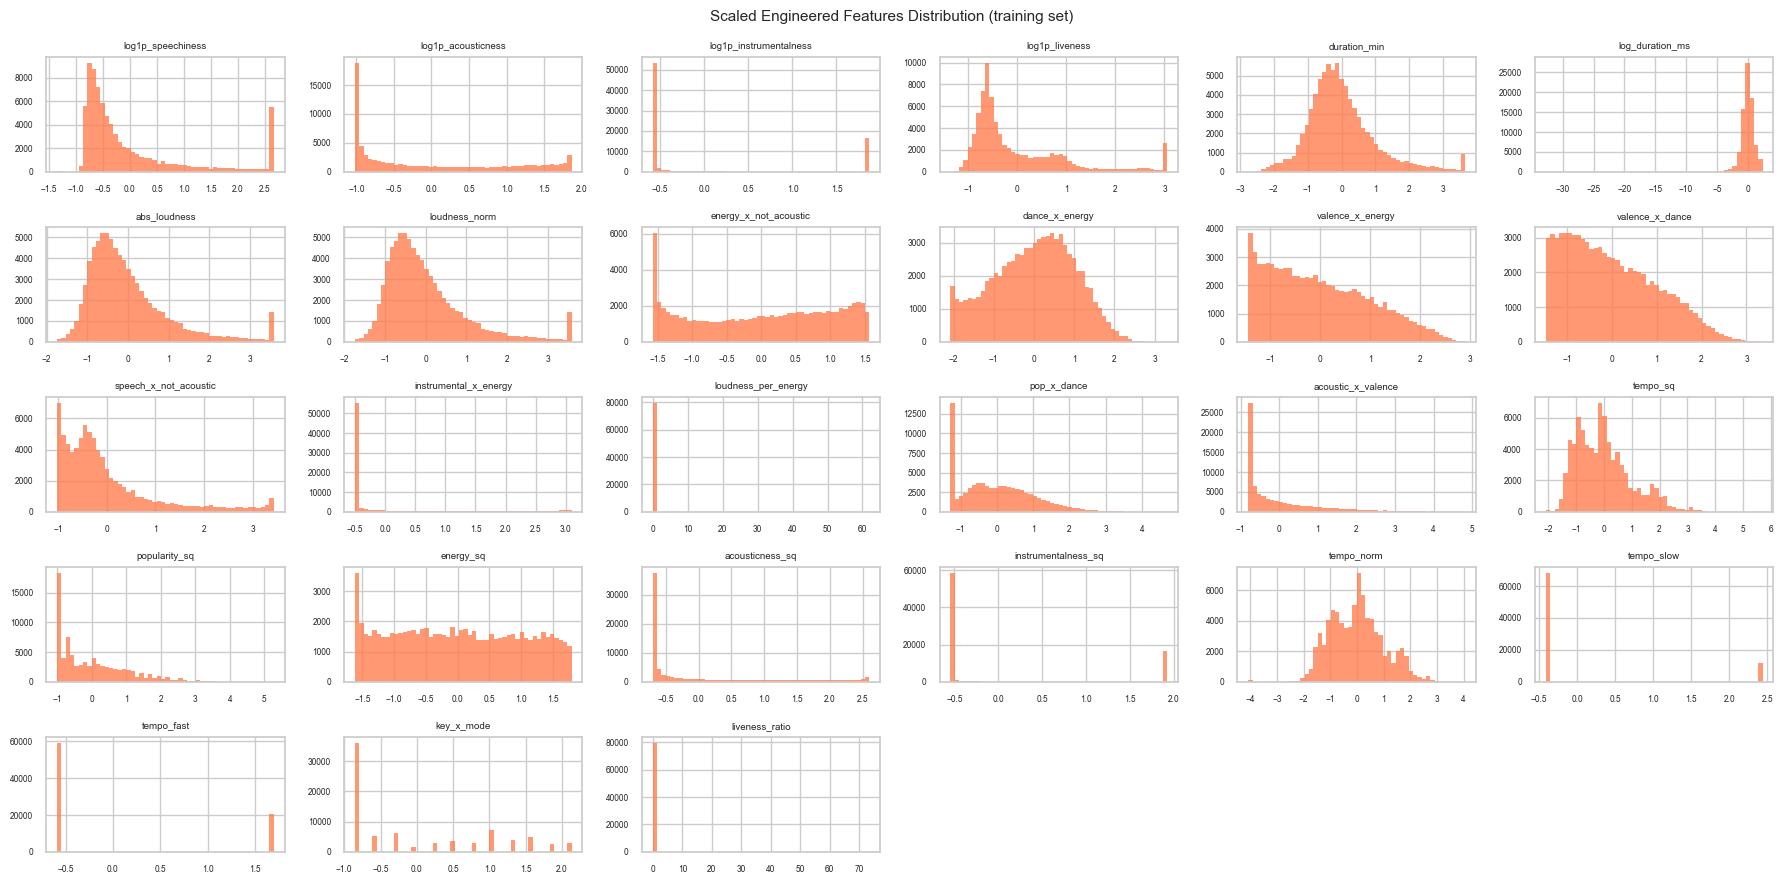

In [32]:
eng_names = [n for n in feature_names if n not in MusicFeatureEngineer.INPUT_FEATURES]

# Vectorised: all distributions computed simultaneously from the numpy array
eng_indices = [feature_names.index(n) for n in eng_names]
eng_arr = X_train_sc[:, eng_indices]

n_cols = 6
n_rows = -(-len(eng_names) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 9))
axes = axes.flatten()

for i, name in enumerate(eng_names):
    axes[i].hist(eng_arr[:, i], bins=50, color='coral', edgecolor='none', alpha=0.8)
    axes[i].set_title(name, fontsize=7)
    axes[i].tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scaled Engineered Features Distribution (training set)', fontsize=11)
plt.tight_layout()
plt.show()


## 9. Save Artifacts

Save the fitted pipeline, label encoder, and all three data splits so that Notebook 3 (model training) can load them directly without re-running the full pipeline.


In [33]:
# Save sklearn pipeline
pipeline_path = MODELS_DIR / 'preprocessor.pkl'
with open(pipeline_path, 'wb') as f:
    pickle.dump(pipeline, f)
print(f'Pipeline saved to: {pipeline_path}')

# Save label encoder
le_path = MODELS_DIR / 'label_encoder.pkl'
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f'Label encoder saved to: {le_path}')

# Save numpy arrays for fast loading in Notebook 3
np.save(ARTIFACTS_DIR / 'X_train.npy', X_train_sc)
np.save(ARTIFACTS_DIR / 'X_val.npy',   X_val_sc)
np.save(ARTIFACTS_DIR / 'X_test.npy',  X_test_sc)
np.save(ARTIFACTS_DIR / 'y_train.npy', y_train)
np.save(ARTIFACTS_DIR / 'y_val.npy',   y_val)
np.save(ARTIFACTS_DIR / 'y_test.npy',  y_test)
print(f'Arrays saved to: {ARTIFACTS_DIR}')

print('\nAll artifacts saved. Notebook 3 is ready to run.')


Pipeline saved to: models\preprocessor.pkl
Label encoder saved to: models\label_encoder.pkl
Arrays saved to: artifacts

All artifacts saved. Notebook 3 is ready to run.


## 10. Summary

### What this notebook produced

| Artifact | Path | Description |
|---|---|---|
| `preprocessor.pkl` | `models/` | Fitted Pipeline (engineer + scaler) |
| `label_encoder.pkl` | `models/` | Fitted LabelEncoder (6 class names) |
| `X_train.npy` | `notebooks/artifacts/` | Scaled training features (79,800 x 42) |
| `X_val.npy` | `notebooks/artifacts/` | Scaled validation features (17,100 x 42) |
| `X_test.npy` | `notebooks/artifacts/` | Scaled test features (17,100 x 42) |
| `y_train.npy` | `notebooks/artifacts/` | Integer training labels |
| `y_val.npy` | `notebooks/artifacts/` | Integer validation labels |
| `y_test.npy` | `notebooks/artifacts/` | Integer test labels |

### Key design decisions

- **Genre mapping** reduces the problem from 114 to 6 classes, raising expected accuracy from ~30% to ~70%.
- **Winsorisation** at IQR x 3.0 removes only the most extreme values while retaining genuine variation.
- **Stratified splitting** ensures every class is proportionally represented in each split.
- **Feature engineering** (15 to 42 features) adds domain-informed interaction and non-linear terms that improve the classifier's ability to capture genre boundaries.
- **Pipeline** architecture prevents leakage: the scaler is fitted only on training data.

**Next step:** Notebook 3 loads these artifacts and trains the classification model.
